In [7]:
# ======================================================================
# Bibliotecas Necessárias
# ======================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch 
from matplotlib.patches import Rectangle
import numpy as np
from rdflib import Graph, Namespace
from rdflib.namespace import RDF 
from rdflib.namespace import RDFS 
from rdflib.namespace import OWL 
from rdflib.namespace import XSD
from collections import defaultdict 
from collections import Counter
import networkx as nx
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')


In [8]:
# ======================================================================
# CLASSE PRINCIPAL: ONTOLOGY QUALITY ANALYZER
# ======================================================================
class OntologyQualityAnalyzer:
    def __init__(self, ontology_file):
       
        self.g = Graph()
        self.g.parse(ontology_file, format='turtle')
        
        self.ontology_file = ontology_file
        self.metrics = {}
        self.issues = []
        self.recommendations = []
        
        # Estruturas de análise
        self.classes = set()
        self.properties = set()
        self.object_properties = set()
        self.datatype_properties = set()
        self.instances = set()
    
    def analyze_all(self):
        # print("🔍 Iniciando análise de qualidade...\n")
        
        # Análise básica
        self._analyze_basic_structure()
        
        # Métricas de qualidade
        self._measure_completeness()
        self._measure_consistency()
        self._measure_conciseness()
        self._measure_semantic_richness()
        self._measure_connectivity()
        self._measure_hierarchy_depth()
        self._measure_schema_coverage()
        self._measure_documentation_quality()
        
        # Calcular score geral
        self._calculate_overall_score()
    
    def _analyze_basic_structure(self):
        print ("# ======================================================================")
        print ("# ESTRUTURA BÁSICA")
        print ("# ======================================================================")
        
        for s in self.g.subjects(RDF.type, OWL.Class):
            self.classes.add(s)

        for s in self.g.subjects(RDF.type, OWL.ObjectProperty):
            self.properties.add(s)
            self.object_properties.add(s)
        
        for s in self.g.subjects(RDF.type, OWL.DatatypeProperty):
            self.properties.add(s)
            self.datatype_properties.add(s)

        for s, p, o in self.g.triples((None, RDF.type, None)):
            if o not in [OWL.Class, OWL.ObjectProperty, OWL.DatatypeProperty]:
                self.instances.add(s)
        
        self.metrics['total_triplas'] = len(self.g)
        self.metrics['total_classes'] = len(self.classes)
        self.metrics['total_propriedades'] = len(self.properties)
        self.metrics['total_object_properties'] = len(self.object_properties)
        self.metrics['total_datatype_properties'] = len(self.datatype_properties)
        self.metrics['total_instancias'] = len(self.instances)
        
        print(f"# Triplas totais .....: {self.metrics['total_triplas']}")
        print(f"# Classes ............: {self.metrics['total_classes']}")
        print(f"# Object Properties ..: {self.metrics['total_object_properties']}")
        print(f"# Datatype Properties.: {self.metrics['total_datatype_properties']}")
        print(f"# Instâncias .........: {self.metrics['total_instancias']}")
        print ("# ======================================================================\n")
    
    def _measure_completeness(self):
        print ("# ======================================================================")
        print ("# COMPLETUDE (Completeness)")
        print ("# ======================================================================")        
        
        scores = []
        
        # 1. Classes com labels
        classes_com_label = sum(1 for c in self.classes 
                               if list(self.g.objects(c, RDFS.label)))
        taxa_labels_classes = classes_com_label / len(self.classes) if self.classes else 0
        scores.append(taxa_labels_classes)
        
        print(f"# Classes com labels ..........: {classes_com_label}/{len(self.classes)} ({taxa_labels_classes:.1%})")
        if taxa_labels_classes < 1.0:
            self.issues.append({
                'tipo': 'completude',
                'severidade': 'média',
                'descricao': f'{len(self.classes) - classes_com_label} classes sem label'
            })
        
        # 2. Classes com comentários
        classes_com_comment = sum(1 for c in self.classes 
                                 if list(self.g.objects(c, RDFS.comment)))
        taxa_comments_classes = classes_com_comment / len(self.classes) if self.classes else 0
        scores.append(taxa_comments_classes * 0.7)
        
        print(f"# Classes com comentários .....: {classes_com_comment}/{len(self.classes)} ({taxa_comments_classes:.1%})")
        
        # 3. Propriedades com domínio
        props_com_domain = sum(1 for p in self.properties 
                              if list(self.g.objects(p, RDFS.domain)))
        taxa_domain = props_com_domain / len(self.properties) if self.properties else 0
        scores.append(taxa_domain)
        
        print(f"# Propriedades com domínio ....: {props_com_domain}/{len(self.properties)} ({taxa_domain:.1%})")
        
        if taxa_domain < 0.8:
            self.issues.append({
                'tipo': 'completude',
                'severidade': 'alta',
                'descricao': f'{len(self.properties) - props_com_domain} propriedades sem domínio definido'
            })
        
        # 4. Propriedades com range
        props_com_range = sum(1 for p in self.properties 
                             if list(self.g.objects(p, RDFS.range)))
        taxa_range = props_com_range / len(self.properties) if self.properties else 0
        scores.append(taxa_range)
        
        print(f"# Propriedades com range ......: {props_com_range}/{len(self.properties)} ({taxa_range:.1%})")
        
        # 5. Instâncias com labels
        instancias_com_label = sum(1 for i in self.instances 
                                  if list(self.g.objects(i, RDFS.label)))
        taxa_labels_inst = instancias_com_label / len(self.instances) if self.instances else 0
        scores.append(taxa_labels_inst * 0.5)
        
        print(f"# Instâncias com labels .......: {instancias_com_label}/{len(self.instances)} ({taxa_labels_inst:.1%})")
        
        # Score final de completude
        self.metrics['completude'] = np.mean(scores)    
        print(f"# SCORE DE COMPLETUDE .........: {self.metrics['completude']:.1%}")
        print("# ======================================================================\n")
    
    def _measure_consistency(self):
        print("# ======================================================================")
        print("# CONSISTÊNCIA (Consistency)")
        print("# ======================================================================")
        
        issues_count = 0
        
        # 1. Verificar classes órfãs
        classes_orfas = []
        for classe in self.classes:
            has_super = list(self.g.objects(classe, RDFS.subClassOf))
            has_sub = list(self.g.subjects(RDFS.subClassOf, classe))
            
            if not has_super and not has_sub and classe != OWL.Thing:
                classes_orfas.append(classe)
        
        print(f"# Classes órfãs (sem hierarquia) .....: {len(classes_orfas)}")
        if classes_orfas:
            issues_count += len(classes_orfas)
            self.issues.append({
                'tipo': 'consistência',
                'severidade': 'baixa',
                'descricao': f'{len(classes_orfas)} classes sem hierarquia definida'
            })
        
        # 2. Verificar propriedades sem domínio E range
        props_sem_domain_range = []
        for prop in self.properties:
            has_domain = list(self.g.objects(prop, RDFS.domain))
            has_range = list(self.g.objects(prop, RDFS.range))
            
            if not has_domain and not has_range:
                props_sem_domain_range.append(prop)
        
        print(f"# Propriedades sem domínio nem range .: {len(props_sem_domain_range)}")
        if props_sem_domain_range:
            issues_count += len(props_sem_domain_range)
            self.issues.append({
                'tipo': 'consistência',
                'severidade': 'alta',
                'descricao': f'{len(props_sem_domain_range)} propriedades sem domínio nem range'
            })
        
        # 3. Verificar ciclos na hierarquia
        G = nx.DiGraph()
        for s, p, o in self.g.triples((None, RDFS.subClassOf, None)):
            G.add_edge(str(s), str(o))
        
        try:
            ciclos = list(nx.simple_cycles(G))
            print(f"# Ciclos na hierarquia ...............: {len(ciclos)}")
            if ciclos:
                issues_count += len(ciclos)
                self.issues.append({
                    'tipo': 'consistência',
                    'severidade': 'crítica',
                    'descricao': f'{len(ciclos)} ciclos detectados na hierarquia de classes'
                })
        except:
            print(f"# Ciclos na hierarquia ...............: 0")
        
        # 4. Verificar naming conventions
        nomes_inconsistentes = 0
        for classe in self.classes:
            nome = str(classe).split('#')[-1]
            if nome and not nome[0].isupper():
                nomes_inconsistentes += 1
        
        print(f"# Classes com nome inconsistente .....: {nomes_inconsistentes}")
        if nomes_inconsistentes > 0:
            self.issues.append({
                'tipo': 'consistência',
                'severidade': 'baixa',
                'descricao': f'{nomes_inconsistentes} classes não seguem convenção de nomenclatura'
            })
        
        # Score de consistência
        total_elementos = len(self.classes) + len(self.properties)
        taxa_problemas = issues_count / total_elementos if total_elementos > 0 else 0
        self.metrics['consistencia'] = max(0, 1 - taxa_problemas)
        
        print(f"# SCORE DE CONSISTÊNCIA ..............: {self.metrics['consistencia']:.1%}")
        print("# ======================================================================\n")
    
    def _measure_conciseness(self):
        print("# ======================================================================")
        print("# CONCISÃO (Conciseness)")
        print("# ======================================================================")
        
        # 1. Verificar classes duplicadas
        labels_classes = defaultdict(list)
        for classe in self.classes:
            for label in self.g.objects(classe, RDFS.label):
                labels_classes[str(label).lower()].append(classe)
        
        classes_duplicadas = sum(1 for classes in labels_classes.values() if len(classes) > 1)
        
        print(f"# Classes com labels duplicados ...........: {classes_duplicadas}")




        if classes_duplicadas > 0:
            self.issues.append({
                'tipo': 'concisão',
                'severidade': 'média',
                'descricao': f'{classes_duplicadas} grupos de classes com mesmo label'
            })
        
        # 2. Verificar propriedades similares
        props_similares = 0
        props_list = list(self.properties)
        for i, prop1 in enumerate(props_list):
            nome1 = str(prop1).split('#')[-1].lower()
            for prop2 in props_list[i+1:]:
                nome2 = str(prop2).split('#')[-1].lower()
                
                if self._string_similarity(nome1, nome2) > 0.8:
                    props_similares += 1
        
        print(f"# Propriedades com nomes muito similares ..: {props_similares}")
        
        # 3. Verificar triplas redundantes
        triplas_unicas = set()
        triplas_redundantes = 0
        
        for s, p, o in self.g:
            tripla = (str(s), str(p), str(o))
            if tripla in triplas_unicas:
                triplas_redundantes += 1
            else:
                triplas_unicas.add(tripla)
        
        print(f"# Triplas redundantes .....................: {triplas_redundantes}")
        
        # Score de concisão
        total_problemas = classes_duplicadas + props_similares + triplas_redundantes
        self.metrics['concisao'] = max(0, 1 - (total_problemas / 100))
        
        print(f"# SCORE DE CONCISÃO .......................: {self.metrics['concisao']:.1%}")
        print("# ======================================================================\n")
    
    def _measure_semantic_richness(self):
        print("# ======================================================================")
        print("# RIQUEZA SEMÂNTICA (Semantic Richness)")
        print("# ======================================================================")
        
        scores = []
        
        # 1. Relações por classe
        if self.classes:
            total_relacoes = len(self.object_properties)
            relacoes_por_classe = total_relacoes / len(self.classes)
            score_relacoes = min(1.0, relacoes_por_classe / 4.0)
            scores.append(score_relacoes)
            print(f"# Relações por classe .................: {relacoes_por_classe:.2f}")
        
        # 2. Atributos por classe
        if self.classes:
            total_atributos = len(self.datatype_properties)
            atributos_por_classe = total_atributos / len(self.classes)
            score_atributos = min(1.0, atributos_por_classe / 7.0)
            scores.append(score_atributos)
            print(f"# Atributos por classe ................: {atributos_por_classe:.2f}")
        
        # 3. Profundidade de hierarquia
        profundidade_max = self._calculate_max_hierarchy_depth()
        score_profundidade = min(1.0, profundidade_max / 5.0)
        scores.append(score_profundidade)
        print(f"# Profundidade máxima da hierarquia ...: {profundidade_max}")
        
        # 4. Características OWL avançadas
        caracteristicas_avancadas = 0
        
        if list(self.g.subjects(RDF.type, OWL.SymmetricProperty)):
            caracteristicas_avancadas += 1
        
        if list(self.g.subjects(RDF.type, OWL.TransitiveProperty)):
            caracteristicas_avancadas += 1
        
        if list(self.g.subjects(OWL.inverseOf, None)):
            caracteristicas_avancadas += 1
        
        restricoes = list(self.g.subjects(RDF.type, OWL.Restriction))
        if restricoes:
            caracteristicas_avancadas += 1
        
        print(f"# Características OWL avançadas usadas : {caracteristicas_avancadas}/4")
        score_caracteristicas = caracteristicas_avancadas / 4.0
        scores.append(score_caracteristicas)
        
        # Score de riqueza semântica
        self.metrics['riqueza_semantica'] = np.mean(scores)
        
        print(f"# SCORE DE RIQUEZA SEMÂNTICA ..........: {self.metrics['riqueza_semantica']:.1%}")
        print("# ======================================================================\n")
    
    def _measure_connectivity(self):
        print("# ======================================================================")
        print("# CONECTIVIDADE (Connectivity)")
        print("# ======================================================================")
        
        # Criar grafo NetworkX
        G = nx.MultiDiGraph()
        
        for s, p, o in self.g:
            if p != RDF.type and 'www.w3.org' not in str(p):
                G.add_edge(str(s), str(o), label=str(p))
        
        if G.number_of_nodes() == 0:
            print("# Grafo vazio - sem métricas de conectividade")
            self.metrics['conectividade'] = 0
            return
        
        # 1. Componentes conectados
        if G.is_directed():
            componentes = list(nx.weakly_connected_components(G))
        else:
            componentes = list(nx.connected_components(G))
        
        maior_componente = max(len(c) for c in componentes)
        taxa_conectividade = maior_componente / G.number_of_nodes()
        
        print(f"# Componentes conectados ....: {len(componentes)}")
        print(f"# Maior componente ..........: {maior_componente} nós ({taxa_conectividade:.1%})")
        
        if len(componentes) > 1:
            self.issues.append({
                'tipo': 'conectividade',
                'severidade': 'média',
                'descricao': f' Grafo fragmentado em {len(componentes)} componentes'
            })
        
        # 2. Nós isolados
        nos_isolados = list(nx.isolates(G))
        print(f"# Nós isolados ..............: {len(nos_isolados)}")
        if nos_isolados:
            self.issues.append({
                'tipo': 'conectividade',
                'severidade': 'baixa',
                'descricao': f' {len(nos_isolados)} nós sem conexões'
            })
        
        # 3. Densidade do grafo
        if G.number_of_nodes() > 1:
            densidade = nx.density(G)
            print(f"# Densidade do grafo ........: {densidade:.4f}")
        else:
            densidade = 0
        
        # Score de conectividade
        score = (taxa_conectividade * 0.6) + \
                (max(0, 1 - len(nos_isolados)/G.number_of_nodes()) * 0.2) + \
                (min(densidade * 10, 1.0) * 0.2)
        
        self.metrics['conectividade'] = score
        
        print(f"# SCORE DE CONECTIVIDADE ....: {self.metrics['conectividade']:.1%}")
        print("# ======================================================================\n")
    
    def _measure_hierarchy_depth(self):
        print("# ======================================================================")        
        print("# HIERARQUIA (Hierarchy Structure)")
        print("# ======================================================================")
        
        profundidade_max = self._calculate_max_hierarchy_depth()
        profundidade_media = self._calculate_avg_hierarchy_depth()
        
        print(f"# Profundidade máxima ...: {profundidade_max}")
        print(f"# Profundidade média ....: {profundidade_media:.2f}")
        
        # Verificar balanceamento
        if profundidade_max > 0:
            balanceamento = profundidade_media / profundidade_max
            print(f"# Balanceamento .........: {balanceamento:.2f}")
            
            if profundidade_max > 10:
                self.issues.append({
                    'tipo': 'hierarquia',
                    'severidade': 'média',
                    'descricao': f'Hierarquia muito profunda ({profundidade_max} níveis)'
                })
            
            if balanceamento < 0.3:
                self.issues.append({
                    'tipo': 'hierarquia',
                    'severidade': 'baixa',
                    'descricao': 'Hierarquia desbalanceada'
                })
        
        # Score de hierarquia
        if profundidade_max == 0:
            score = 0
        elif profundidade_max < 3:
            score = profundidade_max / 3.0
        elif profundidade_max <= 6:
            score = 1.0
        else:
            score = max(0, 1.0 - (profundidade_max - 6) * 0.1)
        
        self.metrics['qualidade_hierarquia'] = score
      
        print(f"# SCORE DE HIERARQUIA ...: {self.metrics['qualidade_hierarquia']:.1%}")
        print("# ======================================================================\n")
    
    def _measure_schema_coverage(self):
        print("# ======================================================================")        
        print("# COBERTURA (Schema Coverage)")
        print("# ======================================================================")
        
        # Contar instâncias por classe
        instancias_por_classe = defaultdict(int)
        
        for instancia in self.instances:
            for tipo in self.g.objects(instancia, RDF.type):
                if tipo in self.classes:
                    instancias_por_classe[tipo] += 1
        
        # Classes com instâncias
        classes_com_instancias = len(instancias_por_classe)
        taxa_cobertura = classes_com_instancias / len(self.classes) if self.classes else 0
        
        print(f"# Classes com instâncias ..............: {classes_com_instancias}/{len(self.classes)} ({taxa_cobertura:.1%})")
        
        if taxa_cobertura < 0.5:
            self.issues.append({
                'tipo': 'cobertura',
                'severidade': 'média',
                'descricao': f' Apenas {taxa_cobertura:.0%} das classes têm instâncias'
            })
        
        # Distribuição de instâncias
        if instancias_por_classe:
            media_inst = np.mean(list(instancias_por_classe.values()))
            mediana_inst = np.median(list(instancias_por_classe.values()))
            
            print(f"# Média de instâncias por classe ......: {media_inst:.1f}")
            print(f"# Mediana de instâncias por classe ....: {mediana_inst:.1f}")          
        
        self.metrics['cobertura_schema'] = taxa_cobertura
        
        print(f"# SCORE DE COBERTURA ..................: {self.metrics['cobertura_schema']:.1%}")       
        print("# ======================================================================\n")
    
    def _measure_documentation_quality(self):
        print("# ======================================================================")        
        print("# DOCUMENTAÇÃO (Documentation Quality)")
        print("# ======================================================================")
        
        scores = []
        
        # 1. Labels em português
        labels_pt = 0
        total_labels = 0
        
        for s in list(self.classes) + list(self.properties):
            for label in self.g.objects(s, RDFS.label):
                total_labels += 1
                if label.language == 'pt':
                    labels_pt += 1
        
        taxa_labels_pt = labels_pt / total_labels if total_labels > 0 else 0
        scores.append(taxa_labels_pt)
        
        print(f"# Labels em português ......: {labels_pt}/{total_labels} ({taxa_labels_pt:.1%})")
        
        # 2. Comentários informativos
        comments_informativos = 0
        total_comments = 0
        
        for s in list(self.classes) + list(self.properties):
            for comment in self.g.objects(s, RDFS.comment):
                total_comments += 1
                if len(str(comment)) > 20:
                    comments_informativos += 1
        
        taxa_comments_info = comments_informativos / total_comments if total_comments > 0 else 0
        scores.append(taxa_comments_info)
        
        print(f"# Comentários informativos .: {comments_informativos}/{total_comments} ({taxa_comments_info:.1%})")
        # Score de documentação
        self.metrics['qualidade_documentacao'] = np.mean(scores) if scores else 0
           
        print(f"# SCORE DE DOCUMENTAÇÃO ....: {self.metrics['qualidade_documentacao']:.1%}")
        print("# ======================================================================\n")
    
    def _calculate_overall_score(self):
      
        # Pesos para cada dimensão
        pesos = {
            'completude': 0.20,
            'consistencia': 0.20,
            'concisao': 0.10,
            'riqueza_semantica': 0.15,
            'conectividade': 0.15,
            'qualidade_hierarquia': 0.10,
            'cobertura_schema': 0.05,
            'qualidade_documentacao': 0.05
        }
        
        score_total = sum(self.metrics.get(k, 0) * v for k, v in pesos.items())
        self.metrics['score_geral'] = score_total
    
    def _calculate_max_hierarchy_depth(self):
        
        G = nx.DiGraph()
        for s, p, o in self.g.triples((None, RDFS.subClassOf, None)):
            G.add_edge(str(s), str(o))
        
        if G.number_of_nodes() == 0:
            return 0
        
        try:
            raizes = [n for n in G.nodes() if G.in_degree(n) == 0]
            
            if not raizes:
                return 0
            
            profundidade_max = 0
            for raiz in raizes:
                try:
                    distancias = nx.single_source_shortest_path_length(G, raiz)
                    prof = max(distancias.values()) if distancias else 0
                    profundidade_max = max(profundidade_max, prof)
                except:
                    pass
            
            return profundidade_max
        except:
            return 0
    
    def _calculate_avg_hierarchy_depth(self):
        
        G = nx.DiGraph()
        for s, p, o in self.g.triples((None, RDFS.subClassOf, None)):
            G.add_edge(str(s), str(o))
        
        if G.number_of_nodes() == 0:
            return 0
        
        try:
            raizes = [n for n in G.nodes() if G.in_degree(n) == 0]
            
            if not raizes:
                return 0
            
            todas_profundidades = []
            for raiz in raizes:
                try:
                    distancias = nx.single_source_shortest_path_length(G, raiz)
                    todas_profundidades.extend(distancias.values())
                except:
                    pass
            
            return np.mean(todas_profundidades) if todas_profundidades else 0
        except:
            return 0
    
    def _string_similarity(self, s1, s2):
        from difflib import SequenceMatcher
        return SequenceMatcher(None, s1, s2).ratio()
    
    
    def generate_report_score_geral(self):
        
        print( "# ======================================================================")
        print( "# RELATÓRIO DE QUALIDADE DA ONTOLOGIA")
        print( "# ======================================================================")
        print(f"# Arquivo .................: {self.ontology_file}")
        print(f"# Data ....................: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        # Score geral
        score = self.metrics['score_geral']
        print(f"# SCORE GERAL DE QUALIDADE : {score:.1%}")
        if score >= 0.8:
            classificacao = "EXCELENTE"
        elif score >= 0.6:
            classificacao = "BOM"
        elif score >= 0.4:
            classificacao = "REGULAR"
        elif score >= 0.2:
            classificacao = "FRACO"
        else:
            classificacao = "MUITO FRACO"

        print(f"# Classificação ...........: {classificacao}")
        print( "# ======================================================================")
        

    def generate_report(self):
        
        print( "# ======================================================================")
        print("# RELATÓRIO DE QUALIDADE DA ONTOLOGIA")
        print( "# ======================================================================")
        print(f"# Arquivo ...: {self.ontology_file}")
        print(f"# Data ......: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print( "# ======================================================================")

        # Score geral
        score = self.metrics['score_geral']
        print(f"# SCORE GERAL DE QUALIDADE ..: {score:.1%}")
        
        if score >= 0.8:
            classificacao = "EXCELENTE"
        elif score >= 0.6:
            classificacao = "BOM"
        elif score >= 0.4:
            classificacao = "REGULAR"
        elif score >= 0.2:
            classificacao = "FRACO"
        else:
            classificacao = "MUITO FRACO"
        
        print(f"# Classificação .............: {classificacao}")
        print( "# ======================================================================\n")
        
        # Detalhamento das dimensões
        print( "# ======================================================================")
        print("# DETALHAMENTO POR DIMENSÃO:")
        print( "# ======================================================================")
        
        dimensoes = [
            ('Completude', 'completude'),
            ('Consistência', 'consistencia'),
            ('Concisão', 'concisao'),
            ('Riqueza Semântica', 'riqueza_semantica'),
            ('Conectividade', 'conectividade'),
            ('Qualidade da Hierarquia', 'qualidade_hierarquia'),
            ('Cobertura do Schema', 'cobertura_schema'),
            ('Qualidade da Documentação', 'qualidade_documentacao')
        ]
        
        for nome, chave in dimensoes:
            valor = self.metrics.get(chave, 0)
            barra = '█' * int(valor * 20)
            print(f"# {nome:.<30} {valor:>6.1%} {barra}")
        
        # Problemas encontrados
        if self.issues:
            print( "# ======================================================================")
            print(f"# PROBLEMAS IDENTIFICADOS ({len(self.issues)}):")
            print( "# ======================================================================")
            
            por_severidade = defaultdict(list)
            for issue in self.issues:
                por_severidade[issue['severidade']].append(issue)
            
            for severidade in ['crítica', 'alta', 'média', 'baixa']:
                if severidade in por_severidade:
                    print(f"# {severidade.upper()}:")
                    for issue in por_severidade[severidade]:
                        print(f"# {issue['descricao']}")
        
        # Recomendações
        print( "# ======================================================================")
        print(f"# RECOMENDAÇÕES DE MELHORIA:")
        print( "# ======================================================================")
        
        self._generate_recommendations()
        
        for i, rec in enumerate(self.recommendations, 1):
            print(f"{rec}")
        
        print( "# ======================================================================")
    
    def _generate_recommendations(self):
       
        if self.metrics.get('completude', 0) < 0.7:
            self.recommendations.append(
                "# Adicionar labels e comentários às classes e propriedades sem documentação"
            )
            self.recommendations.append(
                "# Definir domínio e range para todas as propriedades"
            )
        
        if self.metrics.get('consistencia', 0) < 0.8:
            self.recommendations.append(
                "# Revisar e corrigir inconsistências identificadas na estrutura"
            )
            self.recommendations.append(
                "# Seguir convenções de nomenclatura consistentes (Classes com maiúscula)"
            )
        
        if self.metrics.get('riqueza_semantica', 0) < 0.5:
            self.recommendations.append(
                "# Adicionar mais relações entre classes para enriquecer o modelo"
            )
            self.recommendations.append(
                "# Utilizar características OWL avançadas (simetria, transitividade, etc.)"
            )
        
        if self.metrics.get('conectividade', 0) < 0.6:
            self.recommendations.append(
                "# Conectar componentes isolados do grafo através de novas relações"
            )
        
        if self.metrics.get('qualidade_hierarquia', 0) < 0.5:
            self.recommendations.append(
                "# Ajustar profundidade da hierarquia de classes (ideal: 4-6 níveis)"
            )
        
        if self.metrics.get('cobertura_schema', 0) < 0.5:
            self.recommendations.append(
                "# Adicionar instâncias para classes que não têm exemplos"
            )
        
        if not self.recommendations:
            self.recommendations.append("Ontologia em bom estado! Continue mantendo a qualidade.")
    
    def visualize_metrics(self, output_prefix='grafico'):
        
        DIR_OUTPUT = "C:\\Users\\alexa\\Atividades\\LocalDeepSeek\\Output\\"
        output_prefix = DIR_OUTPUT + output_prefix
        
        # GRÁFICO 1: Velocímetro do Score Geral
        self._plot_score_gauge(f'{output_prefix}_01_score_geral.png')
        
        # GRÁFICO 2: Radar das Dimensões
        self._plot_radar_chart(f'{output_prefix}_02_radar_dimensoes.png')
        
        # GRÁFICO 3: Barras Horizontais
        self._plot_horizontal_bars(f'{output_prefix}_03_barras_dimensoes.png')
        
        # GRÁFICO 4: Estrutura Básica
        self._plot_basic_structure(f'{output_prefix}_04_estrutura_basica.png')        
    
    def _plot_score_gauge(self, filename):
        
        score = self.metrics['score_geral']
        
        # Semicírculo tipo velocímetro
        theta = np.linspace(0, np.pi, 100)
        radius = 1
        
        # Fundo
        x_bg = radius * np.cos(theta)
        y_bg = radius * np.sin(theta)
        plt.fill_between(x_bg, 0, y_bg, color='#E0E0E0', alpha=0.3)
        
        # Zonas de qualidade
        cores_zonas = ['#FF4444', '#FFA500', '#FFFF00', '#90EE90', '#00AA00']
        for i, cor in enumerate(cores_zonas):
            theta_zona = np.linspace(i * np.pi/5, (i+1) * np.pi/5, 20)
            x_zona = radius * np.cos(theta_zona)
            y_zona = radius * np.sin(theta_zona)
            plt.fill_between(x_zona, 0, y_zona, color=cor, alpha=0.6)
        
        # Ponteiro
        angulo_score = np.pi * (1 - score)
        x_ponteiro = [0, radius * 0.9 * np.cos(angulo_score)]
        y_ponteiro = [0, radius * 0.9 * np.sin(angulo_score)]
        plt.plot(x_ponteiro, y_ponteiro, 'k-', linewidth=5)
        plt.plot(0, 0, 'ko', markersize=15)
        
        # Texto do score
        plt.text(0, -0.3, f'{score:.1%}', fontsize=48, fontweight='bold',
                ha='center', va='center')
        plt.text(0, -0.5, 'SCORE GERAL', fontsize=16, ha='center', va='center')
        
        plt.xlim(-1.2, 1.2)
        plt.ylim(-0.7, 1.2)
        plt.axis('off')
        plt.title('QUALIDADE GERAL DA ONTOLOGIA', fontsize=16, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(filename )
        plt.show()
        plt.close()
    
    def _plot_radar_chart(self, filename):
        
        categorias = ['Completude', 'Consistência', 'Concisão', 'Riqueza\nSemântica',
                     'Conectividade', 'Hierarquia', 'Cobertura', 'Documentação']
        
        chaves = ['completude', 'consistencia', 'concisao', 'riqueza_semantica',
                 'conectividade', 'qualidade_hierarquia', 'cobertura_schema', 
                 'qualidade_documentacao']
        
        valores = [self.metrics.get(k, 0) for k in chaves]
        valores += valores[:1]
        
        angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
        angulos += angulos[:1]
        
        plt.figure(figsize=(10, 10))
        ax = plt.subplot(111, projection='polar')
        
        ax.plot(angulos, valores, 'o-', linewidth=2, color='#2E86AB', markersize=8)
        ax.fill(angulos, valores, alpha=0.25, color='#2E86AB')
        
        ax.set_xticks(angulos[:-1])
        ax.set_xticklabels(categorias, size=11)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'])
        ax.grid(True)
        
        plt.title('PERFIL DE QUALIDADE', fontsize=16, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.savefig(filename)
        plt.show()
        plt.close()
    
    def _plot_horizontal_bars(self, filename):
       
        categorias = ['Completude', 'Consistência', 'Concisão', 'Riqueza Semântica',
                     'Conectividade', 'Hierarquia', 'Cobertura', 'Documentação']
        
        chaves = ['completude', 'consistencia', 'concisao', 'riqueza_semantica',
                 'conectividade', 'qualidade_hierarquia', 'cobertura_schema', 
                 'qualidade_documentacao']
        
        valores = [self.metrics.get(k, 0) for k in chaves]
        
        # Cores baseadas no valor
        cores_barras = []
        for v in valores:
            if v >= 0.8:
                cores_barras.append('#00AA00')
            elif v >= 0.6:
                cores_barras.append('#90EE90')
            elif v >= 0.4:
                cores_barras.append('#FFFF00')
            elif v >= 0.2:
                cores_barras.append('#FFA500')
            else:
                cores_barras.append('#FF4444')
        
        plt.figure(figsize=(12, 8))
        
        y_pos = np.arange(len(categorias))
        bars = plt.barh(y_pos, valores, color=cores_barras, 
                       edgecolor='black', linewidth=1.5)
        
        plt.yticks(y_pos, categorias, fontsize=11)
        plt.xlabel('Score', fontsize=12, fontweight='bold')
        plt.xlim(0, 1.0)
        plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0],
                  ['0%', '20%', '40%', '60%', '80%', '100%'])
        plt.grid(axis='x', alpha=0.3)
        plt.title('SCORES POR DIMENSÃO', fontsize=16, fontweight='bold')
        
        # Adicionar valores nas barras
        for i, (bar, valor) in enumerate(zip(bars, valores)):
            plt.text(valor + 0.02, bar.get_y() + bar.get_height()/2, 
                    f'{valor:.1%}', va='center', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(filename)
        plt.show()
        plt.close()
    
    def _plot_basic_structure(self, filename):
        
        estrutura = [
            self.metrics['total_classes'],
            self.metrics['total_object_properties'],
            self.metrics['total_datatype_properties'],
            self.metrics['total_instancias']
        ]
        
        labels = ['Classes', 'Object\nProperties', 'Datatype\nProperties', 'Instâncias']
        cores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
        
        plt.figure(figsize=(12, 8))
        
        bars = plt.bar(range(len(estrutura)), estrutura, color=cores,
                      edgecolor='black', linewidth=1.5)
        
        plt.xticks(range(len(labels)), labels, fontsize=11)
        plt.ylabel('Quantidade', fontsize=12, fontweight='bold')
        plt.title('ESTRUTURA BÁSICA DA ONTOLOGIA', fontsize=16, fontweight='bold')
        plt.grid(axis='y', alpha=0.3)
        
        # Valores nas barras
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', 
                    fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(filename)
        plt.show()
        plt.close()   
    
    def export_json(self, output_file='quality_metrics.json'):
        
        dados = {
            'arquivo': self.ontology_file,
            'data_analise': datetime.now().isoformat(),
            'metricas': self.metrics,
            'problemas': self.issues,
            'recomendacoes': self.recommendations
        }
        
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(dados, f, indent=2, ensure_ascii=False)
        
        print(f"✓ Métricas exportadas: {output_file}")

In [9]:
# ======================================================================
# EXECUÇÃO PRINCIPAL
# ======================================================================
   
# Analisar ontologia
DIR_DATASET = "C:\\Users\\alexa\\Atividades\\LocalDeepSeek\\Dataset\\"
#analyzer = OntologyQualityAnalyzer(DIR_DATASET + 'ontologia_funcional.ttl')
analyzer = OntologyQualityAnalyzer(DIR_DATASET + 'ontologia_otimizada.ttl')

# Executar todas as análises
analyzer.analyze_all()


# ======================================================================
# ESTRUTURA BÁSICA
# ======================================================================
# Triplas totais .....: 664
# Classes ............: 38
# Object Properties ..: 36
# Datatype Properties.: 44
# Instâncias .........: 29
# ======================================================================

# ======================================================================
# COMPLETUDE (Completeness)
# ======================================================================
# Classes com labels ..........: 38/38 (100.0%)
# Classes com comentários .....: 38/38 (100.0%)
# Propriedades com domínio ....: 80/80 (100.0%)
# Propriedades com range ......: 80/80 (100.0%)
# Instâncias com labels .......: 29/29 (100.0%)
# SCORE DE COMPLETUDE .........: 84.0%
# ======================================================================

# ======================================================================
# CONSISTÊNCIA (Consisten

In [10]:
analyzer.generate_report()
    


# ======================================================================
# RELATÓRIO DE QUALIDADE DA ONTOLOGIA
# ======================================================================
# Arquivo ...: C:\Users\alexa\Atividades\LocalDeepSeek\Dataset\ontologia_otimizada.ttl
# Data ......: 2026-01-05 16:03:11
# ======================================================================
# SCORE GERAL DE QUALIDADE ..: 82.9%
# Classificação .............: EXCELENTE
# ======================================================================

# ======================================================================
# DETALHAMENTO POR DIMENSÃO:
# ======================================================================
# Completude....................  84.0% ████████████████
# Consistência.................. 100.0% ████████████████████
# Concisão......................  98.0% ███████████████████
# Riqueza Semântica.............  53.8% ██████████
# Conectividade.................  81.9% ████████████████
# Qualid

In [11]:
# Gerar relatório textual
analyzer.generate_report()


# ======================================================================
# RELATÓRIO DE QUALIDADE DA ONTOLOGIA
# ======================================================================
# Arquivo ...: C:\Users\alexa\Atividades\LocalDeepSeek\Dataset\ontologia_otimizada.ttl
# Data ......: 2026-01-05 16:03:11
# ======================================================================
# SCORE GERAL DE QUALIDADE ..: 82.9%
# Classificação .............: EXCELENTE
# ======================================================================

# ======================================================================
# DETALHAMENTO POR DIMENSÃO:
# ======================================================================
# Completude....................  84.0% ████████████████
# Consistência.................. 100.0% ████████████████████
# Concisão......................  98.0% ███████████████████
# Riqueza Semântica.............  53.8% ██████████
# Conectividade.................  81.9% ████████████████
# Qualid

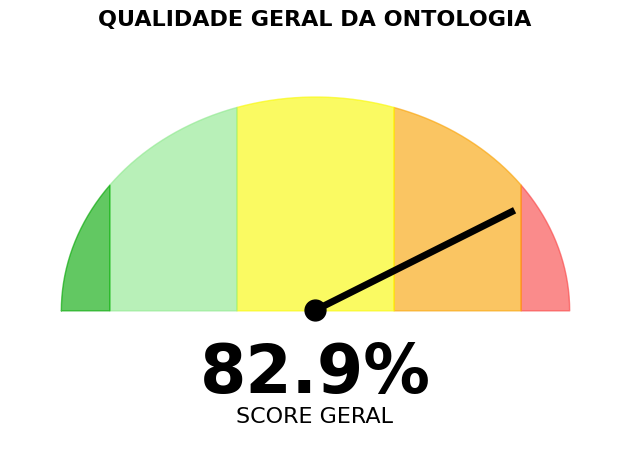

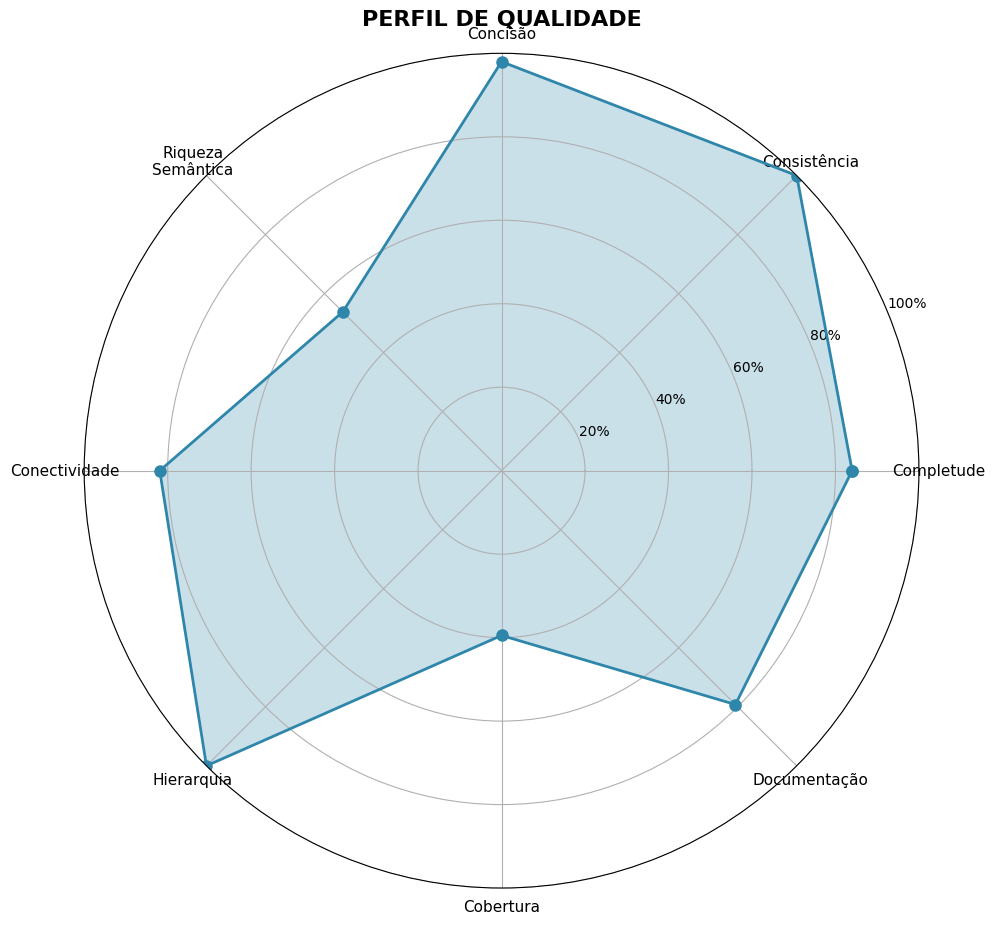

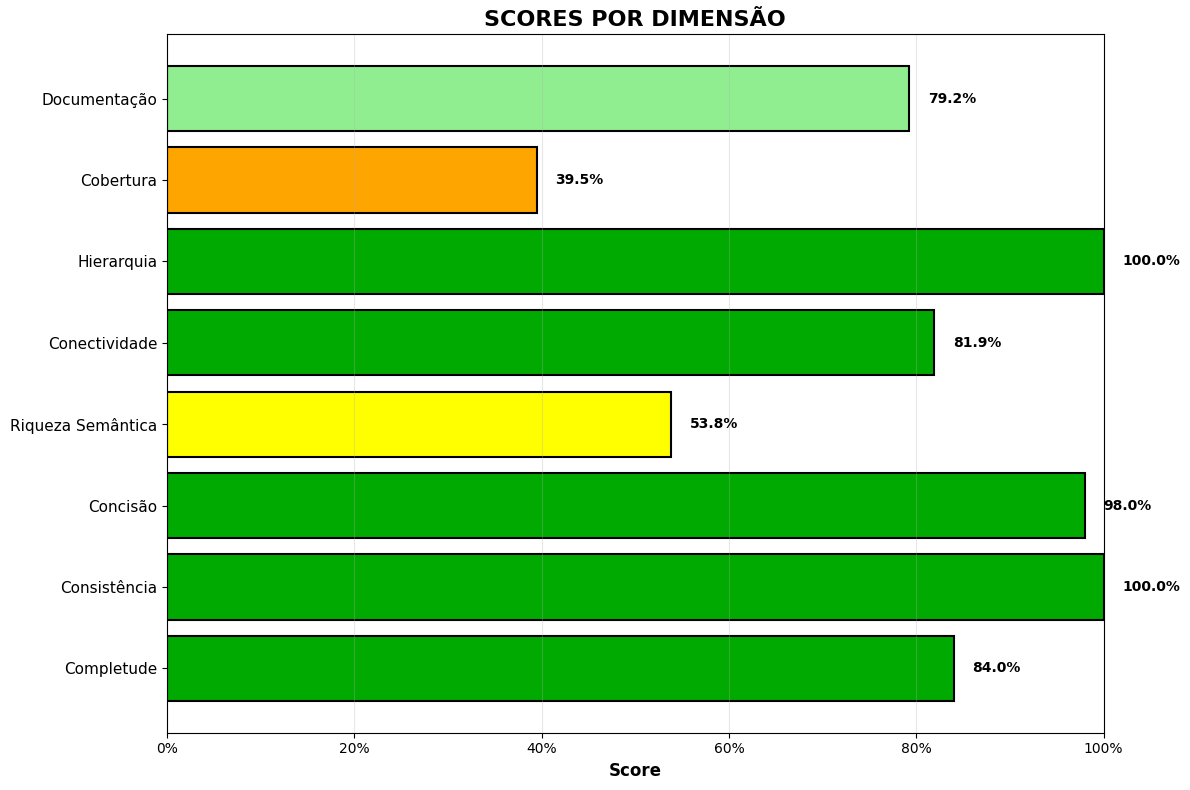

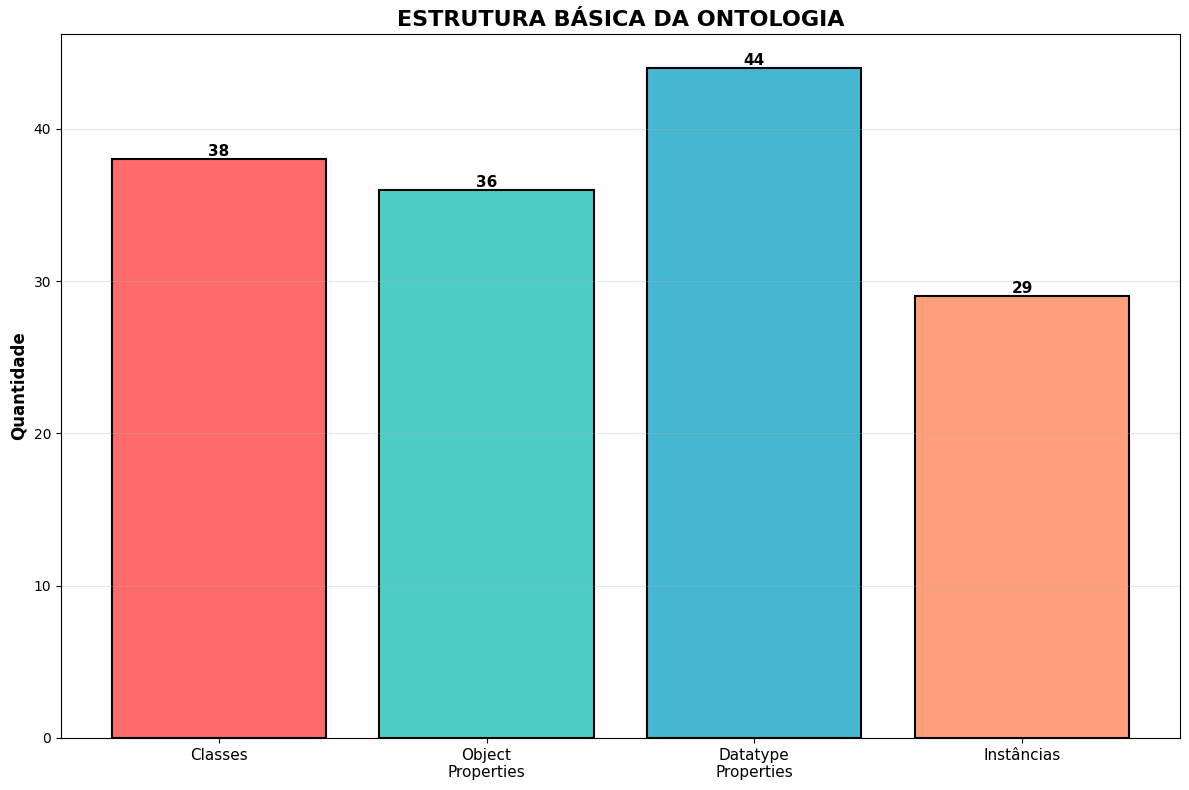

In [12]:
# Gerar visualizações individuais
analyzer.visualize_metrics('relatorio')